# Regularity Components — Top-UUID Examples

In [13]:
from __future__ import annotations

import pickle
from pathlib import Path
from typing import Any, Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpec

from provenance_explorer.registry.registry_all import CACHE_ROOT
from provenance_explorer.plotting.config import apply_style, palette
from provenance_explorer.common_record.object_lookup import ObjectLookup

apply_style()

SWEEP_ROOT = CACHE_ROOT / "regularity_host_sweep_plot"

## helpers

In [14]:
_OL_CACHE: dict[tuple[str, str], Optional[ObjectLookup]] = {}
_ROLE_NAME = {1: "FILE", 2: "SOCKET", 3: "PROCESS", 4: "EXEC"}


def get_lookup(dataset: str, sub_dataset: str) -> Optional[ObjectLookup]:
    key = (dataset, sub_dataset)
    if key not in _OL_CACHE:
        try:
            _OL_CACHE[key] = ObjectLookup.load(dataset, sub_dataset)
        except Exception as e:
            print(f"[lookup] failed to load {dataset}/{sub_dataset}: {e!r}")
            _OL_CACHE[key] = None
    return _OL_CACHE[key]


def describe_uuid(lookup: Optional[ObjectLookup], uuid_str: str) -> dict:
    """Return {role, label} where label is path | ip:port | cmdline depending on role."""
    if lookup is None:
        return {"role": "?", "label": "(no lookup)"}
    info = lookup.get_str(uuid_str)
    if info is None:
        return {"role": "?", "label": "(unresolved)"}
    role = _ROLE_NAME.get(info.role, str(info.role))
    if info.role == 3:  # PROCESS
        label = info.cmdline or info.path or "(no cmdline)"
    elif info.role == 2:  # SOCKET
        if info.ip:
            label = f"{info.ip}:{info.port}" if info.port else info.ip
        else:
            label = info.path or "(no addr)"
    else:  # FILE / EXECUTABLE
        label = info.path or info.cmdline or "(no path)"
    return {"role": role, "label": label}


def top_nodes(payload: dict, r: int, side: str, top_k: int,
              lookup: Optional[ObjectLookup]) -> list[dict]:
    """Top-K entries of A[:, r] or B[:, r]."""
    assert side in ("A", "B")
    vec = payload[side][:, r]
    idx_to_uuid = payload["idx_to_uuid"]
    total = float(vec.sum()) or 1.0
    order = np.argsort(vec)[::-1][:top_k]
    rows = []
    for idx in order:
        uuid_str = idx_to_uuid[int(idx)]
        desc = describe_uuid(lookup, uuid_str)
        rows.append({
            "idx": int(idx),
            "uuid": uuid_str,
            "weight": float(vec[idx]),
            "share": float(vec[idx]) / total,
            "role": desc["role"],
            "label": desc["label"],
        })
    return rows


def load_host_payload(sweep_path: Path, host_id: str) -> tuple[dict, dict]:
    with open(sweep_path, "rb") as fh:
        sweep = pickle.load(fh)
    if host_id not in sweep["hosts"]:
        avail = list(sweep["hosts"].keys())
        raise KeyError(f"host {host_id!r} not in sweep; available: {avail}")
    return sweep["hosts"][host_id], sweep["scope"]

In [15]:
def _truncate_left(s: str, n: int) -> str:
    """
    truncate from the left so the tail of a path/cmdline survives!
    """
    if s is None:
        return ""
    if len(s) <= n:
        return s
    return "…" + s[-(n - 1):]


def _draw_factor(ax, v: np.ndarray, ylabel: str, color: str) -> None:
    """Same stem-on-log-y rendering as the main components figure."""
    v = np.asarray(v, dtype=np.float64)
    x = np.arange(v.size)
    vmax = v.max() if v.size else 0.0
    floor = max(vmax * 1e-4, 1e-12)
    ax.vlines(x, floor, np.maximum(v, floor),
              color=color, linewidth=0.5, alpha=0.9)
    ax.set_yscale("log")
    ax.set_xlim(0, max(1, v.size - 1))
    if vmax > 0:
        ax.set_ylim(bottom=floor, top=vmax * 2.0)
    ax.set_ylabel(ylabel, fontsize=7)
    ax.set_xlabel("node index", fontsize=7)
    ax.tick_params(labelsize=6)


def _draw_top_uuid_panel(ax, src_rows: list[dict], dst_rows: list[dict],
                         color_src: str, color_dst: str,
                         label_chars: int = 42) -> None:
    """Render top-3 src + top-3 dst as a horizontal bar chart with role+label text."""
    rows = [("src", r, color_src) for r in src_rows] + \
           [("dst", r, color_dst) for r in dst_rows]
    n = len(rows)
    y = np.arange(n)[::-1]  # top-of-axes = first src entry
    shares = [row[1]["share"] for row in rows]
    colors = [row[2] for row in rows]

    ax.barh(y, shares, color=colors, height=0.7, alpha=0.85, edgecolor="none")
    ax.set_xlim(0, 1.0)
    ax.set_ylim(-0.5, n - 0.5)
    ax.set_xticks([0.0, 0.5, 1.0])
    ax.tick_params(axis="x", labelsize=6)
    ax.set_yticks([])
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)

    if src_rows and dst_rows:
        ax.axhline(len(dst_rows) - 0.5, color="#cccccc", linewidth=0.6)
    ax.text(1.0, n - 0.5 + 0.05, "src (A)", color=color_src, ha="right", va="bottom",
            fontsize=7, fontweight="bold", transform=ax.transData)
    if dst_rows:
        ax.text(1.0, len(dst_rows) - 0.5 + 0.05, "dst (B)", color=color_dst,
                ha="right", va="bottom", fontsize=7, fontweight="bold",
                transform=ax.transData)

    for yi, (_side, row, _c) in zip(y, rows):
        text = f"[{row['role']}] {_truncate_left(row['label'], label_chars)}  ({row['share'] * 100:.1f}%)"
        ax.text(0.01, yi, text, ha="left", va="center", fontsize=6.5,
                family="monospace")


def render_top_uuid_figure(
    payload: dict,
    scope: dict,
    lookup: Optional[ObjectLookup],
    top_k: int = 3,
    label_chars: int = 42,
) -> Figure:
    """4-column, R-row figure: C, A, B, top-UUID panel."""
    apply_style()
    if payload.get("empty", False):
        fig, ax = plt.subplots(figsize=(6, 2))
        ax.text(0.5, 0.5, f"No events for {payload.get('host_id', '')}",
                ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return fig

    A, B, C = payload["A"], payload["B"], payload["C"]
    meta = payload["meta"]
    scores = payload["analysis"].scores
    order = scores.sort_values("relevance", ascending=False)["r"].tolist()
    R = len(order)
    pal = palette()
    color_C = pal[0]
    color_A = pal[4 % len(pal)]
    color_B = pal[1 % len(pal)]

    fallback_str = "   [fallback: TopK was applied]" if meta.get("fallback_triggered") else ""
    header_lines = [
        f"{scope['dataset']}/{scope['sub_dataset']}  host={payload['host_id']}{fallback_str}",
        f"N={meta.get('N')} (orig {meta.get('N_orig')})  S={meta.get('S')}  "
        f"n_events={meta.get('n_events')}  kept_frac={meta.get('kept_frac', 0):.2f}",
        f"R_best={int(payload['R_best'])}  CC={payload['core_consistency']:.1f}%  "
        f"explained={payload['explained_pct']:.1f}%",
    ]

    fig = plt.figure(figsize=(15, 1.5 + 1.9 * R))
    gs = GridSpec(
        R + 1, 4, figure=fig,
        height_ratios=[0.6] + [1.0] * R,
        width_ratios=[2.4, 1.6, 1.6, 2.6],
        hspace=0.55, wspace=0.28,
    )
    ax_header = fig.add_subplot(gs[0, :])
    ax_header.axis("off")
    ax_header.text(0.0, 0.5, "\n".join(header_lines),
                   ha="left", va="center", fontsize=9, family="monospace")

    for row_i, r in enumerate(order, start=1):
        rel = float(scores.loc[scores["r"] == r, "relevance"].iloc[0])

        # 1. C[:, r] temporal profile
        ax_c = fig.add_subplot(gs[row_i, 0])
        ax_c.plot(C[:, r], color=color_C, linewidth=0.9)
        ax_c.fill_between(np.arange(C.shape[0]), C[:, r], alpha=0.15, color=color_C)
        ax_c.set_xlim(0, C.shape[0] - 1)
        ax_c.set_ylabel(f"C[:,{r}]", fontsize=7)
        ax_c.tick_params(labelsize=6)
        ax_c.set_title(f"component r={r}   relevance={rel:.3f}",
                       loc="left", fontsize=8)

        # 2 & 3. A / B factor stems
        _draw_factor(fig.add_subplot(gs[row_i, 1]), A[:, r], f"A[:,{r}] (src)", color_A)
        _draw_factor(fig.add_subplot(gs[row_i, 2]), B[:, r], f"B[:,{r}] (dst)", color_B)

        # 4. top-UUID panel
        ax_u = fig.add_subplot(gs[row_i, 3])
        src_rows = top_nodes(payload, r, "A", top_k, lookup)
        dst_rows = top_nodes(payload, r, "B", top_k, lookup)
        _draw_top_uuid_panel(ax_u, src_rows, dst_rows,
                             color_src=color_A, color_dst=color_B,
                             label_chars=label_chars)

    return fig

## E3 / cadets

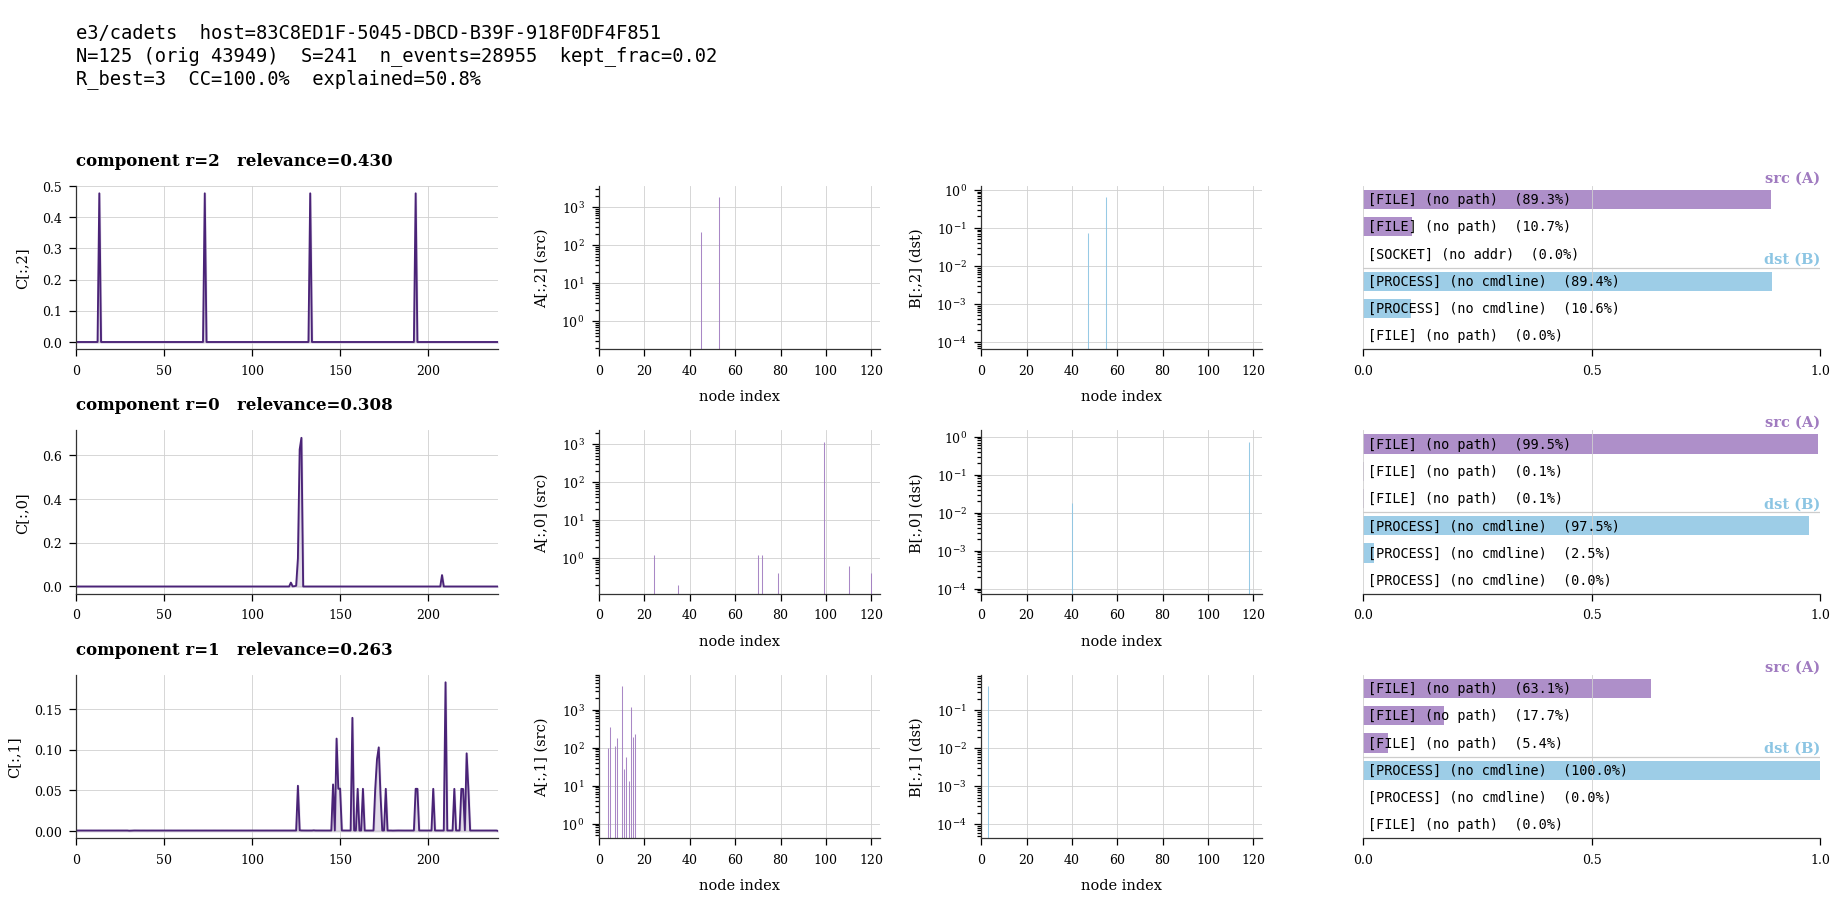

In [16]:
EX_A_DATASET = "e3"
EX_A_SUB = "cadets"
EX_A_SWEEP = SWEEP_ROOT / EX_A_DATASET / EX_A_SUB / "sweep_1522713600000000000-1522800000000000000_4b92c0d9_k10_fb10000.pkl"
EX_A_HOST = "83C8ED1F-5045-DBCD-B39F-918F0DF4F851"

payload_a, scope_a = load_host_payload(EX_A_SWEEP, EX_A_HOST)
lookup_a = get_lookup(EX_A_DATASET, EX_A_SUB)
fig_a = render_top_uuid_figure(payload_a, scope_a, lookup_a, top_k=3)
plt.show()

## OpTC Hostz 51

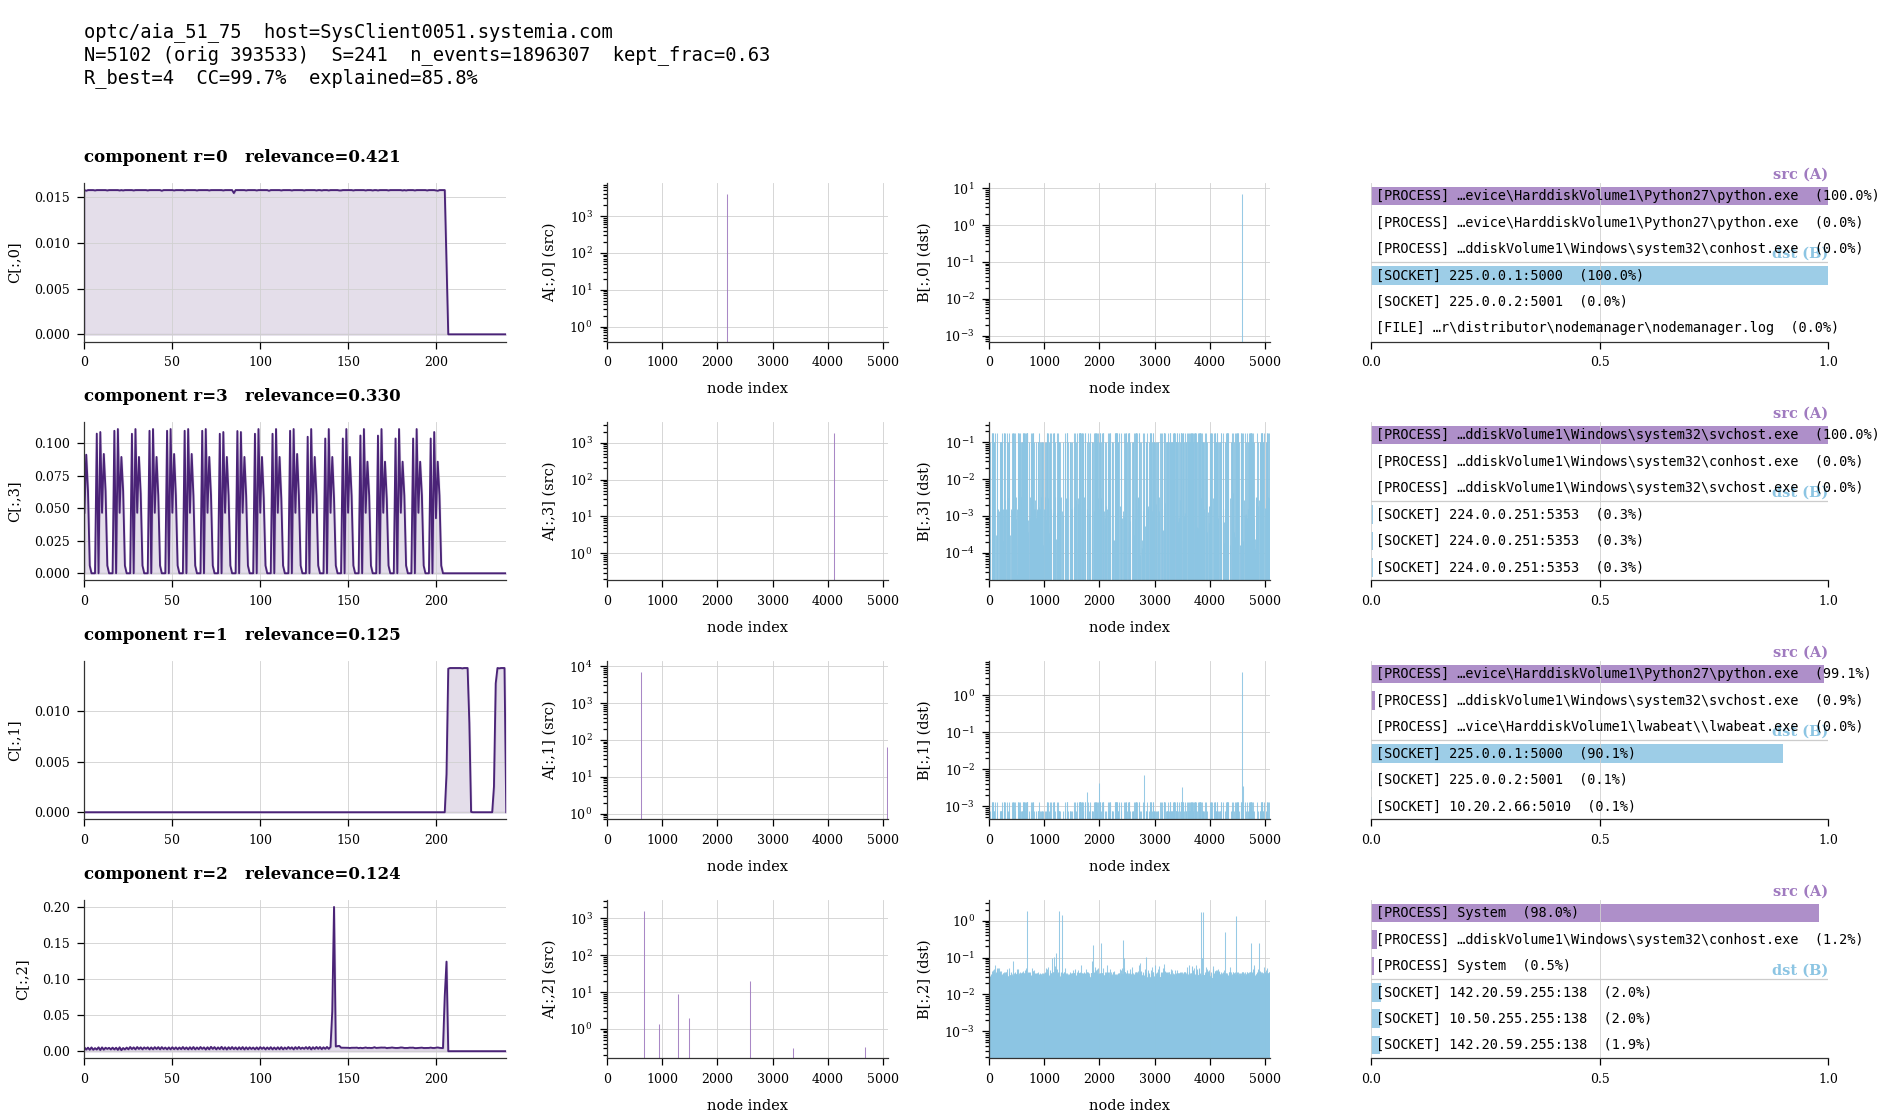

In [17]:
EX_B_DATASET = "optc"
EX_B_SUB = "aia_51_75"
EX_B_SWEEP = SWEEP_ROOT / EX_B_DATASET / EX_B_SUB / "sweep_1568937600000000000-1569024000000000000_4b92c0d9_k10_fb10000.pkl"
EX_B_HOST = "SysClient0051.systemia.com"

payload_b, scope_b = load_host_payload(EX_B_SWEEP, EX_B_HOST)
lookup_b = get_lookup(EX_B_DATASET, EX_B_SUB)
fig_b = render_top_uuid_figure(payload_b, scope_b, lookup_b, top_k=3)
plt.show()

In [18]:
# SWEEP_PATH = SWEEP_ROOT / "e3" / "cadets" / "sweep_1522713600000000000-1522800000000000000_4b92c0d9_k10_fb10000.pkl"
# HOST_ID = "83C8ED1F-5045-DBCD-B39F-918F0DF4F851"
# DATASET, SUB = "e3", "cadets"
#
# payload, scope = load_host_payload(SWEEP_PATH, HOST_ID)
# lookup = get_lookup(DATASET, SUB)
# fig = render_top_uuid_figure(payload, scope, lookup, top_k=3)
# plt.show()